# Modelado

In [77]:
import pandas as pd
import numpy as np 
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn import metrics  

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

## Funciones y utilidades

In [ ]:
def carga_info(data):
    drop_cols = [
        'Municipio', 
        'Departamento', 
        'EVI_Min_Date', 
        'EVI_Max_Date', 
        'NDVI_Min_Date', 
        'NDVI_Max_Date', 
        'NDVI_Max_Count', 
        'Latitude', 
        'Longitude', 
        'Producto', 
        'Área Cosechada', 
        'Área Sembrada', 
        'Ciclo',
        'Producción'
        ]
    
    #Creación de nuevas variables necesarias
    data['Mpio'] = data['Municipio'].str.strip()+'_'+data['Departamento'].str.strip()
    data['Flag_covid'] = np.where(data['Year']==2020, 1, 0)
    data.rename(columns={'EVI_Max_Count':'Resolucion'}, inplace=True)
    #Eliminación de columnas innecesarias
    data.drop(columns=drop_cols, inplace=True)
    #Eliminación de nuelos -- esto puede cambiar si decidimos hacer imputacion
    data.dropna(inplace=True)
    #Ordenamiento
    data = data[['Year', 'Mpio', 't2m', 'd2m', 'tp', 'ssrd', 'e', 'stl1', 'Resolucion',
       'EVI_Min_Minimum', 'EVI_Max_Maximum', 'EVI_Avg_StdDev',
       'EVI_Median_Median', 'EVI_Avg_Mean', 'NDVI_Min_Minimum',
       'NDVI_Max_Maximum', 'NDVI_Avg_StdDev', 'NDVI_Median_Median',
       'NDVI_Avg_Mean', 'Flag_covid', 'Rendimiento']]
    
    print(f'Data cargada para {base}')
    data.info()
    return data

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    predictors = X_train.columns
    results = []
    
    for pred in predictors:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies
        if X.dtypes[0] == 'object':
            X = pd.get_dummies(X, drop_first=True)
        
            # Agregar intercepto
        X = sm.add_constant(X)
        
        # Fit modelo
        mod = sm.OLS(y_train, X)
        res = mod.fit()
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer coeficiente y p-value (puede haber varias columnas si hubo dummies)
        for var in X.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def univariate_ols_analysis(df, target='Rendimiento', test_size=0.2, random_state=42, verbose=True):
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop(columns=[target]),
        df[target],
        test_size=test_size,
        random_state=random_state
    )
    
    results = []
    
    for pred in X_train.columns:
        
        X = X_train[[pred]].copy()
        
        # Convertir categóricas a dummies SI es necesario
        if X.dtypes.iloc[0] == 'object' or str(X.dtypes.iloc[0]).startswith('category'):
            X = pd.get_dummies(X, drop_first=True)
        
        # 🔑 FORZAR a numérico (CLAVE para evitar tu error)
        X = X.apply(pd.to_numeric, errors='coerce')
        y = pd.to_numeric(y_train, errors='coerce')
        
        # Eliminar NaNs generados
        data = pd.concat([X, y], axis=1).dropna()
        X_clean = data.drop(columns=[target])
        y_clean = data[target]
        
        # Agregar constante
        X_clean = sm.add_constant(X_clean)
        
        # Fit
        try:
            mod = sm.OLS(y_clean, X_clean)
            res = mod.fit()
        except Exception as e:
            print(f"Error con predictor {pred}: {e}")
            continue
        
        if verbose:
            print(f"\nResultados para predictor: {pred}")
            print(res.summary())
        
        # Extraer resultados
        for var in X_clean.columns:
            if var != 'const':
                results.append({
                    'predictor': pred,
                    'variable_model': var,
                    'R2': res.rsquared,
                    'F_stat': res.fvalue,
                    'coef': res.params[var],
                    'p_value': res.pvalues[var],
                })
    
    df_results = pd.DataFrame(results)
    df_results.sort_values(by='R2', ascending=False, inplace=True)
    df_results.reset_index(drop=True, inplace=True)
    
    return df_results

def plot_corr_with_target(df, target='Rendimiento', drop_cols=None, plot=True):
    
    # Copia del df
    data = df.copy()
    
    # Eliminar columnas si se especifica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Mantener solo numéricas (evita errores)
    data = data.select_dtypes(include='number')
    
    # Correlación
    corr_df = data.corr()
    
    # Plot
    if plot:
        plt.figure(figsize=(12,8))
        sns.heatmap(
            corr_df,
            cmap='coolwarm',
            center=0,
            annot=True,
            fmt=".2f",
            linewidths=0.4
        )
        plt.title("Correlation Matrix")
        plt.show()
    
    # Ranking respecto al target
    corr_target = corr_df[target].sort_values(ascending=False)
    
    return corr_df, corr_target

In [162]:
def random_forest_feature_importance(
    df,
    target='Rendimiento',
    drop_cols=None,
    test_size=0.2,
    random_state=42,
    n_estimators=100
):
    
    # Copia del dataframe
    data = df.copy()
    
    # Eliminar columnas si aplica
    if drop_cols:
        data = data.drop(columns=drop_cols)
    
    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        data.drop(columns=[target]),
        data[target],
        test_size=test_size,
        random_state=random_state
    )
    
    # Modelo
    RF = RandomForestRegressor(
        random_state=random_state,
        n_estimators=n_estimators
    )
    
    RF.fit(X_train, y_train)
    
    # Feature importance
    feat_imp_df = pd.DataFrame({
        'feature': RF.feature_names_in_,
        'importance': RF.feature_importances_
    })
    
    feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False).reset_index(drop=True)
    
    return feat_imp_df, RF

## 1.Carga de información

In [66]:
df_ago_nov = pd.read_excel("../Data anual/data_anual_ago_nov.xlsx")
df_sep_dec = pd.read_excel("../Data anual/data_anual_sep_dec.xlsx")
df_total = pd.read_excel("../Data anual/data_anual_total.xlsx")

df_ago_nov = carga_info(df_ago_nov)
df_sep_dec = carga_info(df_sep_dec)
df_total = carga_info(df_total)

Data cargada para ../Data anual/data_total.xlsx
<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 0 to 431
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                426 non-null    int64  
 1   Mpio                426 non-null    object 
 2   t2m                 426 non-null    float64
 3   d2m                 426 non-null    float64
 4   tp                  426 non-null    float64
 5   ssrd                426 non-null    float64
 6   e                   426 non-null    float64
 7   stl1                426 non-null    float64
 8   Resolucion          426 non-null    int64  
 9   EVI_Min_Minimum     426 non-null    float64
 10  EVI_Max_Maximum     426 non-null    float64
 11  EVI_Avg_StdDev      426 non-null    float64
 12  EVI_Median_Median   426 non-null    float64
 13  EVI_Avg_Mean        426 non-null    float64
 14  NDVI_Min_Minimum    426 non-null    float64
 15  NDVI_Max_Maxim

## 2.Revision Total

In [ ]:
df_total_it = df_total[~df_total['Year'].isin([2024])]
df_total_it.drop(columns=['Year'], inplace=True)
df_total_it_dummies = pd.get_dummies(df_total_it, drop_first=True)

In [157]:
total_regressions = univariate_ols_analysis(df_total_it_dummies, target='Rendimiento')


Resultados para predictor: t2m
                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.983
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.160
Time:                        15:50:35   Log-Likelihood:                -53.339
No. Observations:                 321   AIC:                             110.7
Df Residuals:                     319   BIC:                             118.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.644

,predictor,variable_model,R2,F_stat,coef,p_value
0,ssrd,ssrd,0.103603,36.869262,1.458664e-07,3.587486e-09
1,EVI_Median_Median,EVI_Median_Median,0.036779,12.180327,1.952234e+00,5.509269e-04
2,NDVI_Max_Maximum,NDVI_Max_Maximum,0.026370,8.639803,1.783621e+00,3.528990e-03
3,EVI_Avg_Mean,EVI_Avg_Mean,0.022767,7.432013,1.496042e+00,6.761433e-03
4,EVI_Max_Maximum,EVI_Max_Maximum,0.018026,5.855763,9.316490e-01,1.608470e-02
5,stl1,stl1,0.008977,2.889580,1.932826e-02,9.012894e-02
6,NDVI_Median_Median,NDVI_Median_Median,0.008200,2.637511,8.276247e-01,1.053546e-01
7,t2m,t2m,0.006177,1.982669,1.810577e-02,1.600833e-01
8,e,e,0.005614,1.800929,-1.475868e+02,1.805546e-01
9,NDVI_Avg_Mean,NDVI_Avg_Mean,0.003715,1.189387,4.674379e-01,2.762763e-01


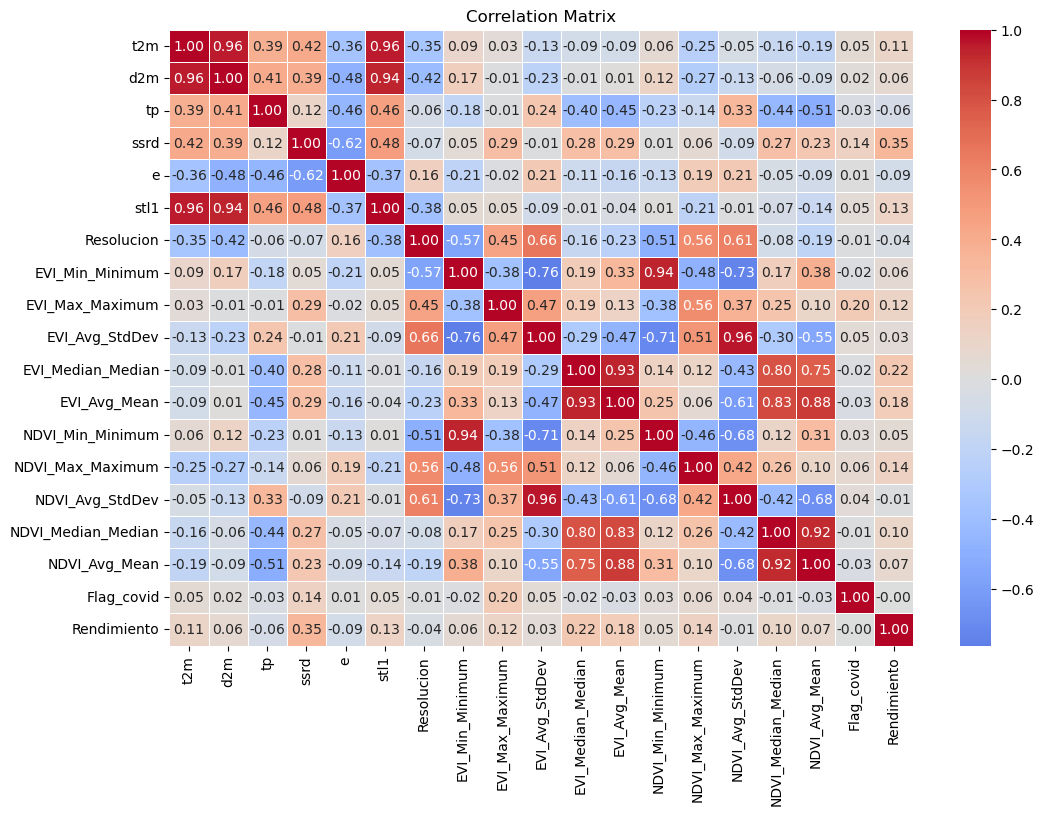

Rendimiento           1.000000
ssrd                  0.345375
EVI_Median_Median     0.222867
EVI_Avg_Mean          0.181461
NDVI_Max_Maximum      0.137152
stl1                  0.126328
EVI_Max_Maximum       0.120372
t2m                   0.113964
NDVI_Median_Median    0.101897
NDVI_Avg_Mean         0.074628
d2m                   0.064966
EVI_Min_Minimum       0.057137
NDVI_Min_Minimum      0.053289
EVI_Avg_StdDev        0.033591
Flag_covid           -0.003425
NDVI_Avg_StdDev      -0.007823
Resolucion           -0.039692
tp                   -0.062384
e                    -0.085023
Name: Rendimiento, dtype: float64

In [161]:
corr_matrix, corr_target_total = plot_corr_with_target(
    df_total_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

corr_target_total

In [163]:
feat_imp_df_total, model = random_forest_feature_importance(
    df_total_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

feat_imp_df_total

,feature,importance
0,ssrd,0.165840
1,EVI_Median_Median,0.139340
2,NDVI_Max_Maximum,0.075716
3,tp,0.062001
4,NDVI_Min_Minimum,0.056726
5,EVI_Max_Maximum,0.055688
6,e,0.051751
7,EVI_Avg_Mean,0.049631
8,EVI_Avg_StdDev,0.047478
9,NDVI_Median_Median,0.044580


## Revision agosto - noviembre

In [164]:
df_ago_nov_it = df_ago_nov[~df_ago_nov['Year'].isin([2024])]
df_ago_nov_it.drop(columns=['Year'], inplace=True)
df_ago_nov_it_dummies = pd.get_dummies(df_ago_nov_it, drop_first=True)

In [165]:
total_regressions_ago_nov = univariate_ols_analysis(df_ago_nov_it_dummies, target='Rendimiento')


Resultados para predictor: t2m
                            OLS Regression Results                            
Dep. Variable:            Rendimiento   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.267
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.261
Time:                        15:56:46   Log-Likelihood:                -53.698
No. Observations:                 321   AIC:                             111.4
Df Residuals:                     319   BIC:                             118.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.702

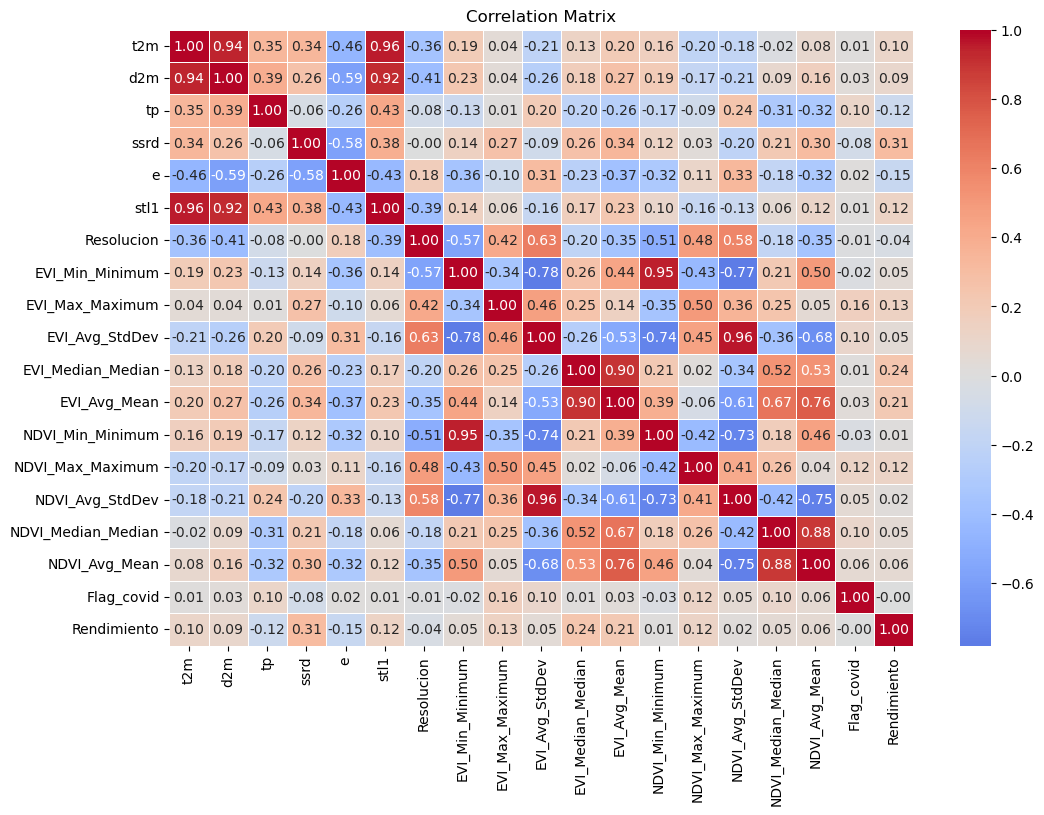

Rendimiento           1.000000
ssrd                  0.305417
EVI_Median_Median     0.240225
EVI_Avg_Mean          0.214356
EVI_Max_Maximum       0.131397
stl1                  0.124482
NDVI_Max_Maximum      0.118384
t2m                   0.103988
d2m                   0.090209
NDVI_Avg_Mean         0.057740
NDVI_Median_Median    0.049383
EVI_Avg_StdDev        0.046912
EVI_Min_Minimum       0.045086
NDVI_Avg_StdDev       0.021494
NDVI_Min_Minimum      0.011222
Flag_covid           -0.003425
Resolucion           -0.039692
tp                   -0.115313
e                    -0.153583
Name: Rendimiento, dtype: float64

In [166]:
corr_matrix, corr_target_ago_nov = plot_corr_with_target(
    df_ago_nov_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

corr_target_ago_nov

In [167]:
feat_imp_df_ago_nov, model = random_forest_feature_importance(
    df_ago_nov_it,
    target='Rendimiento',
    drop_cols=['Mpio']
)

feat_imp_df_ago_nov

,feature,importance
0,ssrd,0.129489
1,EVI_Median_Median,0.098411
2,NDVI_Max_Maximum,0.081350
3,EVI_Avg_Mean,0.080811
4,tp,0.079266
5,EVI_Min_Minimum,0.064047
6,NDVI_Avg_StdDev,0.058742
7,EVI_Avg_StdDev,0.054604
8,EVI_Max_Maximum,0.047210
9,e,0.045722
